# Notebook 04 — Modèle de référence : régression linéaire simple (affichage des résultats)


**Ce que le script a fait :**
1. Charger `panel_pret_modelisation.parquet` et construire les **fenêtres d'entraînement
   glissantes/extensives** (voir `fenetres.py` et `config.py`)
2. Pour **chaque fenêtre**, entraîner une **régression linéaire simple** (OLS, sans
   régularisation, sans aucun hyperparamètre à choisir) sur le train de cette fenêtre
3. Mettre bout à bout les prédictions de toutes les fenêtres et calculer le **R²
   hors-échantillon à la Gu, Kelly & Xiu (2020)**
4. Estimer la significativité des variables par **Fama-MacBeth** (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal des expériences

**Pourquoi une régression linéaire simple comme tout premier modèle ?** C'est le benchmark
le plus basique possible : aucune régularisation, aucune sélection de variables, aucun
hyperparamètre. Elle sert de **plancher de comparaison** — si l'Elastic Net ou LightGBM ne
font pas mieux sur `test`, leur complexité supplémentaire n'apporte rien de concret.

## 0. Import et chargement des résultats

In [22]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('04_regression_lineaire')
print(rap.resume())

# Fichiers de resultats ecrits par le script (chemins dans config.py)
resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_REGRESSION_LINEAIRE_PAR_FENETRE)

Rapport '04_regression_lineaire' produit le 2026-08-16T15:00:57


## 1. Données et fenêtres d'entraînement

Les fenêtres sont construites par `fenetres.generer_fenetres` à partir des paramètres de
`config.py` (`TYPE_FENETRE`, `ANNEES_TRAIN_INITIAL`, `ANNEES_VALIDATION`,
`ANNEES_TEST_PAR_FENETRE`) — les mêmes pour les notebooks 05 et 06, pour rester comparable.

In [23]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Predicteurs : {rap.valeur('n_caracteristiques')} caracteristiques retenues + "
      f"{rap.valeur('n_macro_predicteurs')} macro = {rap.valeur('n_predicteurs')} au total")
print()
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
rap.table('resume_fenetres')

Panel complet : (2615807, 49)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 49) (198002 a 202112)
Predicteurs : 30 caracteristiques retenues + 8 macro = 38 au total

Mode : expanding | 12 fenetres generees


,fenetre,train_debut,train_fin,n_mois_train,n_annees_train,validation_debut,validation_fin,n_annees_validation,test_debut,test_fin,annee_test
0,0,198002,199712,215,18,199801,200912,12,201001,201012,2010
1,1,198002,199912,239,20,200001,201012,11,201101,201112,2011
2,2,198002,200112,263,22,200201,201112,10,201201,201212,2012
3,3,198002,200312,287,24,200401,201212,9,201301,201312,2013
4,4,198002,200512,311,26,200601,201312,8,201401,201412,2014
5,5,198002,200712,335,28,200801,201412,7,201501,201512,2015
6,6,198002,200912,359,30,201001,201512,6,201601,201612,2016
7,7,198002,201112,383,32,201201,201612,5,201701,201712,2017
8,8,198002,201312,407,34,201401,201712,4,201801,201812,2018
9,9,198002,201412,419,35,201501,201812,4,201901,201912,2019


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Le R² habituel compare les erreurs du modèle à celles d'une prédiction naïve égale à la
**moyenne** de `y`. GKX comparent plutôt à une prédiction naïve de **zéro** (ce qui revient
à supposer qu'on ne peut rien prédire des rendements, plutôt que de miser sur un retour à
la moyenne historique) :

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

La fonction est définie une seule fois, dans `fenetres.py`, réutilisée telle quelle par les
3 modèles du projet.

## 3. Résultat de l'entraînement, fenêtre par fenêtre

Une régression linéaire simple (OLS) n'a **aucun hyperparamètre à choisir** : elle est
entraînée directement sur le `train` de chaque fenêtre, sans recherche sur `validation`
(qui ne sert ici que de point de contrôle intermédiaire).

In [24]:
print(f"Duree totale d'entrainement (toutes fenetres) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print(f"Predictions de test cumulees : {rap.valeur('n_predictions_test')} lignes")
print()
resultats_par_fenetre

Duree totale d'entrainement (toutes fenetres) : 130.8 s
Predictions de test cumulees : 669550 lignes



,fenetre,annee_test,n_train,r2_oos_train,r2_oos_validation,r2_oos_test
0,0,2010,1106697,0.020873,-0.060449,-0.518289
1,1,2011,1274823,0.017444,-0.122914,-1.258942
2,2,2012,1429430,0.014393,-0.253888,-1.499566
3,3,2013,1564728,0.014183,-0.267150,-0.364255
4,4,2014,1694462,0.011780,-0.107669,-0.109706
5,5,2015,1825906,0.010604,-0.078262,-0.146370
6,6,2016,1946257,0.008847,-0.016841,-0.001919
7,7,2017,2056316,0.008951,-0.004067,0.003574
8,8,2018,2163427,0.009492,-0.013995,-0.034060
9,9,2019,2218241,0.009128,-0.013081,0.004227


## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

⚠️ **Pourquoi ne pas juste faire la moyenne des R²_oos de chaque fenêtre ?** Parce que les
fenêtres n'ont pas toutes le même nombre d'observations, et parce que la formule du R²_oos
(des sommes au numérateur et au dénominateur, pas un ratio de moyennes) n'est pas linéaire —
une moyenne simple donnerait un poids disproportionné aux fenêtres les plus courtes ou aux
périodes les plus calmes. La bonne pratique (celle de GKX) est de **mettre toutes les
prédictions bout à bout d'abord**, puis de calculer un seul R²_oos sur cette série complète.

In [25]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0110
R2_oos validation (pooled, toutes fenetres) : -0.1089
R2_oos test       (pooled, toutes fenetres) : -0.2432



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,Regression lineaire,expanding,12,0.011038,-0.108933,-0.2432,8c18417f667d7c19


8 macro dans le top 20.



,|coef| moyen,signe stable,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
predicteur,,,,,,,,,,,,,,
macro_tbl,0.0263,True,-0.0525,-0.0488,-0.0466,-0.0423,-0.0254,-0.0192,-0.0174,-0.0144,-0.0144,-0.0130,-0.0109,-0.0111
macro_ep,0.0128,False,0.0218,0.0274,0.0288,0.0309,0.0173,0.0147,-0.0008,-0.0025,-0.0030,-0.0024,-0.0020,-0.0023
turn,0.0125,True,-0.0106,-0.0101,-0.0124,-0.0137,-0.0134,-0.0132,-0.0138,-0.0133,-0.0128,-0.0125,-0.0124,-0.0122
macro_dfy,0.0102,True,0.0121,0.0150,0.0156,0.0107,0.0163,0.0156,0.0046,0.0061,0.0055,0.0068,0.0074,0.0067
std_turn,0.0094,True,0.0100,0.0100,0.0104,0.0103,0.0100,0.0095,0.0095,0.0090,0.0088,0.0086,0.0085,0.0083
macro_tms,0.0092,True,-0.0166,-0.0143,-0.0132,-0.0128,-0.0088,-0.0054,-0.0076,-0.0074,-0.0071,-0.0064,-0.0053,-0.0054
zerotrade,0.0087,True,-0.0063,-0.0077,-0.0096,-0.0103,-0.0099,-0.0093,-0.0095,-0.0090,-0.0086,-0.0082,-0.0081,-0.0080
macro_dp,0.0086,False,-0.0083,-0.0171,-0.0151,-0.0099,0.0063,0.0064,0.0048,0.0072,0.0073,0.0073,0.0067,0.0068
macro_bm,0.0086,False,0.0195,0.0183,0.0139,0.0067,-0.0138,-0.0150,0.0078,0.0030,0.0031,0.0009,-0.0005,0.0001


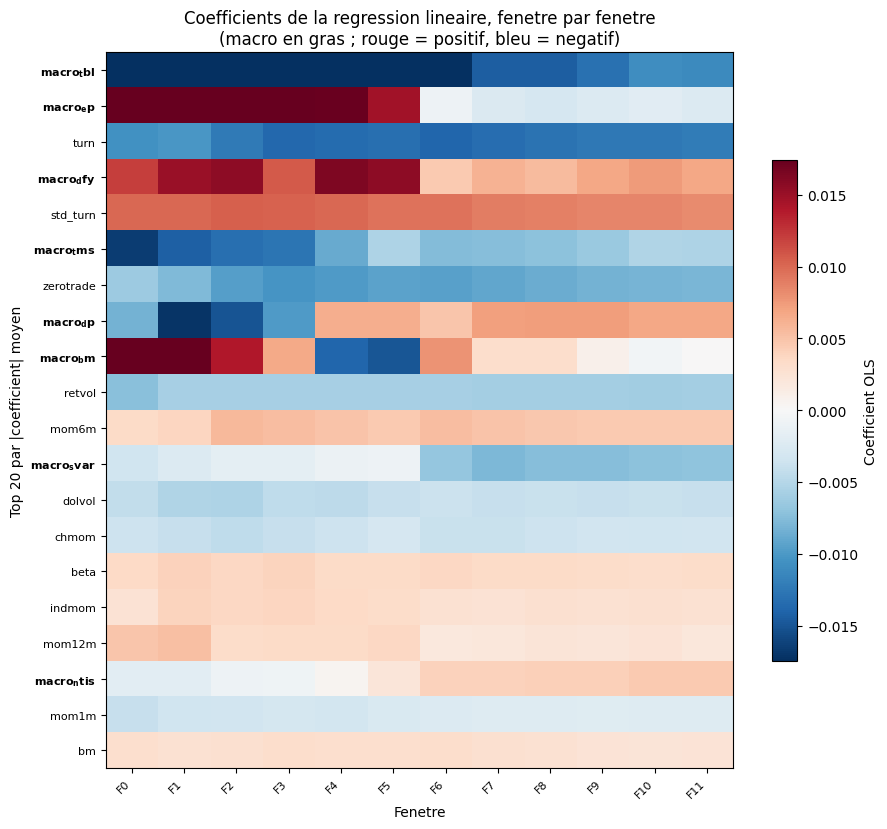

In [26]:
## 5bis. Coefficients OLS du top 20, fenetre par fenetre (macro incluses)
import chemins

N_TOP = 20

coefs_fenetres = pd.read_parquet(chemins.sortie('coefficients_par_fenetre_lineaire'))
matrice = coefs_fenetres.T                            # lignes = predicteurs, colonnes = fenetres
matrice.columns = [f"F{n}" for n in coefs_fenetres.index]

# Top N par amplitude moyenne, du plus important au moins important
ordre = matrice.abs().mean(axis=1).sort_values(ascending=False)
top = ordre.index[:N_TOP]
matrice = matrice.loc[top]

# --- Tableau ---
tableau = matrice.copy()
signes = np.sign(coefs_fenetres[top])
tableau.insert(0, '|coef| moyen', ordre[:N_TOP])
tableau.insert(1, 'signe stable', (signes.abs().sum() == signes.sum().abs()).values)
tableau.index.name = 'predicteur'

print(f"{sum(p.startswith('macro_') for p in top)} macro dans le top {N_TOP}.\n")
display(tableau.round(4))

# --- Graphique, meme selection et meme ordre ---
graphique = matrice.iloc[::-1]        # le plus important en haut avec origin='lower'
echelle = np.nanquantile(np.abs(graphique.values), 0.95)
n_lignes, n_colonnes = graphique.shape

fig, ax = plt.subplots(figsize=(2.5 + 0.55 * n_colonnes, 2 + 0.32 * n_lignes))
image = ax.imshow(graphique.values, aspect='auto', cmap='RdBu_r',
                  vmin=-echelle, vmax=echelle, origin='lower')

ax.set_xticks(range(n_colonnes))
ax.set_xticklabels(graphique.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n_lignes))
ax.set_yticklabels([f"$\\bf{{{p}}}$" if p.startswith('macro_') else p
                    for p in graphique.index], fontsize=8)
ax.set_xlabel("Fenetre")
ax.set_ylabel(f"Top {N_TOP} par |coefficient| moyen")
ax.set_title("Coefficients de la regression lineaire, fenetre par fenetre\n"
             "(macro en gras ; rouge = positif, bleu = negatif)")
fig.colorbar(image, ax=ax, label="Coefficient OLS", shrink=0.7)
plt.tight_layout()
plt.show()

## 6. Significativité des variables (Fama-MacBeth 1973, t-stats de Newey-West)

La section précédente ne regarde que les coefficients de la **dernière fenêtre** — ça ne dit
rien sur leur **stabilité dans le temps** ni sur leur **significativité**. Deux mauvaises
idées pour combler ça :

- **Un OLS pooled sur les ~N×T lignes du panel** donnerait des t-stats complètement gonflées :
  les résidus sont fortement corrélés **entre entreprises d'un même mois** (mêmes chocs de
  marché), donc le nombre d'observations effectivement indépendantes est bien plus proche du
  nombre de **mois** que du nombre de lignes (Petersen, 2009).
- **Les coefficients d'une seule fenêtre** (section 6) ne sont qu'un instantané.

**La solution standard : Fama-MacBeth (1973).** Chaque **mois**, une régression en coupe
transversale du rendement excédentaire sur les caractéristiques (T régressions au total) ;
puis moyenne temporelle des T coefficients de chaque caractéristique, avec un écart-type de
**Newey-West** (robuste à l'autocorrélation et l'hétéroscédasticité) pour un t-stat valide.

⚠️ **Les 8 prédicteurs macro sont exclus.** Une régression cross-sectionnelle mensuelle n'a
par construction **aucune variance à expliquer** sur une variable macro : elle prend la même
valeur pour toutes les entreprises d'un mois donné, donc elle est parfaitement colinéaire
avec la constante — son coefficient n'est pas identifiable mois par mois.

ℹ️ **Portée** : contrairement aux sections 1 à 5, cette analyse utilise **tout l'historique
disponible**, pas seulement le train d'une fenêtre. C'est volontaire : l'objectif est
descriptif (quelles caractéristiques sont, en moyenne et de façon fiable, associées au
rendement futur), pas de ré-évaluer la capacité prédictive hors-échantillon.

In [27]:
if not rap.valeur('fama_macbeth_execute'):
    print("La section 6bis n'a pas ete calculee (script lance avec --sans-fama-macbeth).")
    print("Relance : python scripts/etape04_modele_lineaire.py")
else:
    significativite = pd.read_parquet(config.FICHIER_SIGNIFICATIVITE_REGRESSION_LINEAIRE)

    print(f"{rap.valeur('fm_n_regressions')} regressions cross-sectionnelles mensuelles estimees "
          f"({rap.valeur('fm_n_predicteurs')} predicteurs, periode "
          f"{rap.valeur('fm_periode')[0]} a {rap.valeur('fm_periode')[1]}).")
    print(f"Nombre de lags Newey-West : {rap.valeur('fm_nb_lags_nw')}")
    print()
    print(f"{rap.valeur('fm_nb_significatifs')} / {rap.valeur('fm_n_teste')} predicteurs "
          "significatifs a 5% (t-stat de Newey-West).")
    print("⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par")
    print("   pur hasard (pas de correction de Bonferroni/FDR ici) -- a lire comme un classement")
    print("   indicatif, pas comme une liste 'certifiee'.")
    print()
    print("Top 20 des predicteurs les plus significatifs (|t-stat| decroissant) :")
    display(significativite.head(20).round(4))

503 regressions cross-sectionnelles mensuelles estimees (30 predicteurs, periode 198002 a 202112).
Nombre de lags Newey-West : 5

15 / 30 predicteurs significatifs a 5% (t-stat de Newey-West).
⚠️ Avec autant de tests simultanes, une partie de ces significativites est attendue par
   pur hasard (pas de correction de Bonferroni/FDR ici) -- a lire comme un classement
   indicatif, pas comme une liste 'certifiee'.

Top 20 des predicteurs les plus significatifs (|t-stat| decroissant) :


,coef_moyen_fm,erreur_type_nw,t_stat_nw,p_value_nw,pct_mois_signe_positif,significatif_5pct
predicteur,,,,,,
turn,-0.0091,0.0010,-8.7860,0.0000,27.0378,True
std_turn,0.0054,0.0007,7.8598,0.0000,65.8052,True
retvol,-0.0067,0.0010,-6.7872,0.0000,37.7734,True
mom1m,-0.0056,0.0009,-6.4001,0.0000,36.1829,True
zerotrade,-0.0057,0.0010,-5.8895,0.0000,37.7734,True
agr,0.0019,0.0003,5.5731,0.0000,61.6302,True
indmom,0.0035,0.0006,5.5257,0.0000,63.4195,True
gma,0.0025,0.0006,4.5510,0.0000,60.2386,True
mom6m,0.0030,0.0008,3.6766,0.0002,61.0338,True


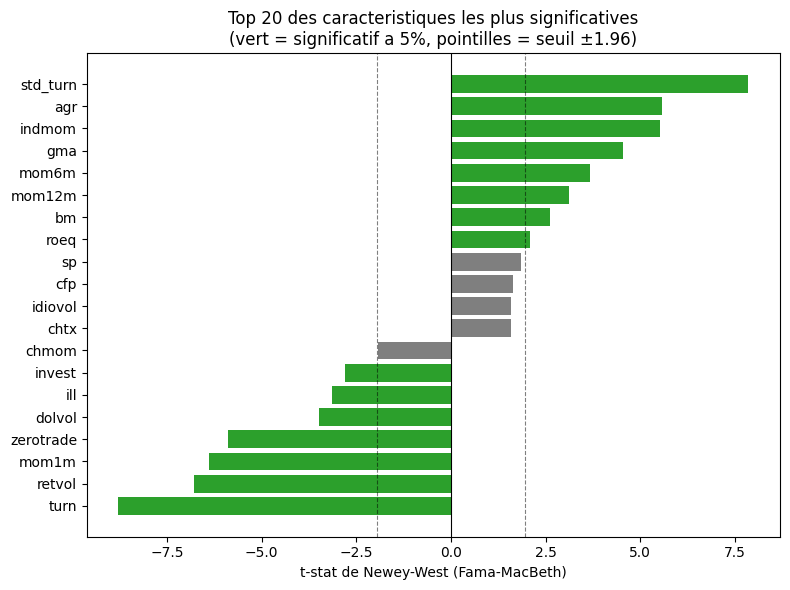

In [28]:
if rap.valeur('fama_macbeth_execute'):
    top20 = significativite.head(20).sort_values('t_stat_nw')
    couleurs = ['tab:green' if s else 'tab:gray' for s in top20['significatif_5pct']]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top20.index, top20['t_stat_nw'], color=couleurs)
    ax.axvline(0, color='black', linewidth=0.8)
    for seuil in (-1.96, 1.96):
        ax.axvline(seuil, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel("t-stat de Newey-West (Fama-MacBeth)")
    ax.set_title("Top 20 des caracteristiques les plus significatives\n"
                 "(vert = significatif a 5%, pointilles = seuil ±1.96)")
    plt.tight_layout()
    plt.show()

## 6bis. Où et quand chaque caractéristique compte : deux lectures complémentaires

### Panneau A — fréquence de significativité

Pour chaque mois, on teste le coefficient de la caractéristique dans la régression
transversale de ce mois-là (t-stat classique, seuil |t| ≥ 1.96, soit significatif a 5%). La case affiche la
**part des mois de la fenêtre où ce test est rejeté**, sans distinction de signe.

Le test est fait **au niveau du mois, pas de la fenêtre** : avec ~3000 entreprises pour une
centaine de paramètres, l'écart-type du coefficient est estimé avec précision. Un t-stat
calculé sur les 12 coefficients d'une fenêtre, lui, reposerait sur un écart-type estimé à
partir de 12 points seulement — trop instable pour être lu case par case.


### Panneau B — cohérence signée

Le panneau A ignore la direction : une caractéristique dont le coefficient est fortement
positif la moitié du temps et fortement négatif l'autre moitié y apparaît comme très
active. Le panneau B mesure précisément si ces mois vont, ou non, dans le même sens.

Pour chaque fenêtre, en notant `b(1), ..., b(n)` les coefficients de ses `n` mois :

    cohérence = moyenne( b(t) ) / moyenne( |b(t)| )

Le numérateur laisse les mois de signes opposés s'annuler ; le dénominateur, non. Le rapport
vit donc dans `[-1, +1]` :

- **+1** : tous les mois de la fenêtre sont positifs — effet parfaitement régulier, à la hausse
- **-1** : tous les mois sont négatifs — effet parfaitement régulier, à la baisse
- **0** : les mois s'annulent exactement — le coefficient change de direction

Le rapport est **sans échelle** : il ne dépend ni de l'amplitude du coefficient ni des unités
du prédicteur, ce qui rend les lignes comparables entre elles. Il ne dit rien sur la force de
l'effet — c'est le rôle du panneau A.

⚠️ Sur une fenêtre de 12 mois, du bruit pur donne une cohérence d'environ ±0.25 en valeur
absolue, pas 0. Ne lisez pas 0.3 comme « incohérent » : c'est le plancher. Le passer à
`BLOC = 'train'` allonge les colonnes et abaisse ce plancher.

### Comment lire les deux ensemble

| Panneau A | Panneau B | Lecture |
|---|---|---|
| élevé | proche de ±1 | effet fort **et** régulier sur cette période |
| élevé | proche de 0 | la variable compte tous les mois, mais **retourne sa direction** — instable, difficilement exploitable par un modèle linéaire à coefficients fixes |
| faible | quelconque | rien de détectable sur cette période (le panneau B n'a alors pas de sens : il décrit la direction d'un effet inexistant) |
| élevé puis bas selon les colonnes | — | l'effet s'est **éteint** (ou éveillé) à une date qu'on lit sur l'axe horizontal |

Les caractéristiques sont classées du bas vers le haut par **fréquence globale de
significativité**, toutes fenêtres confondues.

C:\Users\aless\AppData\Local\Temp\ipykernel_3704\2755115501.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


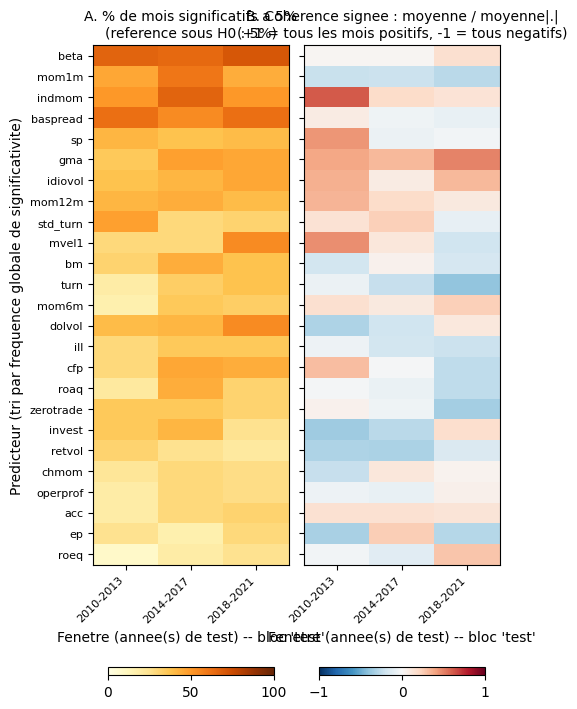

In [29]:
## 6ter. Frequence de significativite et coherence de signe, fenetre par fenetre
import fenetres
import chemins

BLOC = 'test'        # 'test' (hors-echantillon) ou 'train' (colonnes plus longues)
N_AFFICHES = 25      # None = tous les predicteurs
MOIS_MINIMUM = 6     # une fenetre plus courte est ignoree

coefs_fm = pd.read_parquet(chemins.sortie('coefficients_fm_mensuels'))
erreurs_fm = pd.read_parquet(chemins.sortie('erreurs_types_fm_mensuels'))

# Significativite au niveau du MOIS : t-stat sur ~3000 entreprises, bien estime
t_mensuels = coefs_fm / erreurs_fm
significatif = t_mensuels.abs() >= 1.96

liste_fenetres = fenetres.generer_fenetres(
    coefs_fm.index,
    type_fenetre=config.TYPE_FENETRE,
    annees_train_initial=config.ANNEES_TRAIN_INITIAL,
    annees_validation=config.ANNEES_VALIDATION,
    annees_test_par_fenetre=config.ANNEES_TEST_PAR_FENETRE,
    reduction_validation_par_fenetre=config.REDUCTION_VALIDATION_PAR_FENETRE,
    fenetre_debut_reduction_validation=config.FENETRE_DEBUT_REDUCTION_VALIDATION,
    annees_validation_minimum=config.ANNEES_VALIDATION_MINIMUM,
)

blocs, blocs_sig = {}, {}
for f in liste_fenetres:
    mois = [m for m in f[BLOC] if m in coefs_fm.index]
    if len(mois) >= MOIS_MINIMUM:
        blocs[f['annee_test']] = coefs_fm.loc[mois]
        blocs_sig[f['annee_test']] = significatif.loc[mois]

if not blocs:
    raise ValueError(
        f"Aucune fenetre n'a au moins {MOIS_MINIMUM} mois dans le bloc '{BLOC}'. "
        "Verifie MOIS_MINIMUM et config.ANNEES_TEST_PAR_FENETRE."
    )

# Panneau A : % de mois de la fenetre ou le coefficient est significatif a 5%
panneau_a = pd.DataFrame({k: b.mean() * 100 for k, b in blocs_sig.items()})
# Panneau B : coherence SIGNEE, moyenne / moyenne|.|, entre -1 et +1
moyenne_absolue = pd.DataFrame({k: b.abs().mean() for k, b in blocs.items()})
panneau_b = (pd.DataFrame({k: b.mean() for k, b in blocs.items()})
             / moyenne_absolue.replace(0, np.nan))

# Ordre commun aux deux panneaux : le plus souvent significatif, toutes fenetres
# confondues, en haut de l'ordonnee
ordre = significatif.mean().reindex(panneau_a.index).sort_values()
lignes = ordre.index[-N_AFFICHES:] if N_AFFICHES else ordre.index
panneau_a = panneau_a.loc[lignes]
panneau_b = panneau_b.loc[lignes]

n_lignes, n_colonnes = panneau_a.shape

fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(3 + 0.75 * n_colonnes, 2.5 + 0.28 * n_lignes),
    sharey=True, gridspec_kw={'wspace': 0.08})

image_a = ax_a.imshow(panneau_a.values, aspect='auto', cmap='YlOrBr',
                      vmin=0, vmax=100, origin='lower')
ax_a.set_title("A. % de mois significatifs a 5%\n(reference sous H0 : 5%)", fontsize=10)
fig.colorbar(image_a, ax=ax_a, orientation='horizontal', pad=0.14, shrink=0.85)

image_b = ax_b.imshow(panneau_b.values, aspect='auto', cmap='RdBu_r',
                      vmin=-1, vmax=1, origin='lower')
ax_b.set_title("B. Coherence signee : moyenne / moyenne|.|\n"
               "(+1 = tous les mois positifs, -1 = tous negatifs)", fontsize=10)
fig.colorbar(image_b, ax=ax_b, orientation='horizontal', pad=0.14, shrink=0.85)

for ax in (ax_a, ax_b):
    ax.set_xticks(range(n_colonnes))
    ax.set_xticklabels(panneau_a.columns, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel(f"Fenetre (annee(s) de test) -- bloc '{BLOC}'")

ax_a.set_yticks(range(n_lignes))
ax_a.set_yticklabels(panneau_a.index, fontsize=8)
ax_a.set_ylabel("Predicteur (tri par frequence globale de significativite)")

plt.tight_layout()
plt.show()

## 9. Résumé

- Régression linéaire simple (OLS), **sans régularisation et sans hyperparamètre** —
  ré-entraînée à chaque fenêtre, jamais une seule fois sur tout l'historique.
- Même métrique (`R²_oos` à la GKX, pooled) et même logique de fenêtres que les autres
  modèles du projet, pour rester comparable.
- Aucun coefficient n'est mis à 0 : toutes les variables sont gardées, y compris celles qui
  n'apportent rien — à comparer avec l'Elastic Net au notebook suivant.
- **Significativité (section 6bis)** : Fama-MacBeth + Newey-West, beaucoup plus fiable qu'un
  coefficient de la dernière fenêtre ou qu'un p-value d'OLS pooled (invalide ici).

**Étape suivante :** `python scripts/etape05_modele_elastic_net.py`.